# Public Wolffia Four-Run Comparison

This notebook compares all four public `Wolffia australiana` runs from `PRJNA1124135` after STARsolo counting and leaf-primary/root-benchmark transfer prediction.

The goal is to move from per-run processing to cross-run interpretation: do the four public runs show similar QC, feature coverage, acceptance rates, and broad transfer-label patterns?


## tl;dr

- All four public Wolffia runs were successfully processed through the same STARsolo-to-transfer-model workflow.
- Each run has the same Waus8730 gene feature space and the same model feature bridge coverage: 309 of 340 model features.
- The model is intentionally conservative: most cells remain `ambiguous` in every run.
- The most reproducible accepted signal is `photosynthetic_or_assimilation`, present in all four runs.
- The root-benchmark layer accepts almost no cells, supporting its role as a conservative secondary check rather than the primary Wolffia interpretation layer.
- The next biological analysis step is native cluster/marker review across all four runs, especially to check whether the accepted photosynthetic/assimilation-like cells occupy coherent expression regions.


## Context & Methods

### Key assumptions

- The four public runs come from `PRJNA1124135` and are interpreted as two dawn-like and two dusk-like public samples based on repository metadata.
- STARsolo was run against the `Waus8730.v1` reference using read 3 as cDNA and read 2 as the cell-barcode/UMI read.
- The transfer model uses an Arabidopsis-space feature matrix generated through the Waus8730 orthogroup bridge.
- Accepted transfer labels are provisional broad-program predictions, not final Wolffia cell-type annotations.

### Input files

This notebook expects processed outputs on the external drive:

```text
/Volumes/LaCie/wolffia_single_cell/results/processed_h5ad/
/Volumes/LaCie/wolffia_single_cell/results/model_application/<RUN>/
```

If those files are not available, the notebook can still load the repo-tracked four-run comparison CSV as a lightweight fallback.


In [1]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
try:
    import anndata as ad
except ImportError:
    ad = None

plt.style.use("default")
plt.rcParams["figure.dpi"] = 130
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
EXTERNAL_ROOT = Path("/Volumes/LaCie/wolffia_single_cell")
RUNS = ["SRR29417746", "SRR29417745", "SRR29417744", "SRR29417743"]

metadata_path = PROJECT_ROOT / "data/metadata/wolffia_public_run_accessions.csv"
repo_comparison_path = PROJECT_ROOT / "data/metadata/public_wolffia_four_run_model_comparison.csv"

print("Project root:", PROJECT_ROOT)
print("External root exists:", EXTERNAL_ROOT.exists())
print("Repo fallback comparison exists:", repo_comparison_path.exists())


Project root: /Users/bella/Documents/Wolffia Single-Cell Atlas Pipeline Before the Data Arrive
External root exists: True
Repo fallback comparison exists: True


## Data

Load run metadata, model summaries, prediction tables, and raw-count AnnData objects when available. The raw-count objects are used only to compute per-cell QC medians.


In [2]:
run_metadata = pd.read_csv(metadata_path)
run_metadata = run_metadata.loc[run_metadata["run_accession"].isin(RUNS)].copy()
run_metadata["run_accession"] = pd.Categorical(run_metadata["run_accession"], RUNS, ordered=True)
run_metadata = run_metadata.sort_values("run_accession")
run_metadata[["run_accession", "library_name", "condition_or_compartment", "notes"]]


,run_accession,library_name,condition_or_compartment,notes
0,SRR29417746,Dawn1,dawn,time-of-day scRNA-seq replicate 1
1,SRR29417745,Dawn2,dawn,time-of-day scRNA-seq replicate 2
2,SRR29417744,Dusk1,dusk,time-of-day scRNA-seq replicate 1
3,SRR29417743,Dusk2,dusk,time-of-day scRNA-seq replicate 2


In [3]:
def load_live_run_summary(run: str) -> dict:
    summary_path = EXTERNAL_ROOT / f"results/model_application/{run}/combined_application_summary.json"
    predictions_path = EXTERNAL_ROOT / f"results/model_application/{run}/combined_leaf_root_predictions.csv"
    raw_h5ad_path = EXTERNAL_ROOT / f"results/processed_h5ad/{run}_raw_counts.h5ad"
    audit_path = EXTERNAL_ROOT / f"results/waus8730_bridge/{run}_model_feature_mapping_audit.csv"

    if not summary_path.exists() or not predictions_path.exists():
        raise FileNotFoundError(f"Missing live model outputs for {run}")

    summary = json.loads(summary_path.read_text())
    predictions = pd.read_csv(predictions_path)
    audit = pd.read_csv(audit_path) if audit_path.exists() else None

    median_raw_umis = np.nan
    median_raw_genes = np.nan
    waus8730_genes = np.nan
    if ad is not None and raw_h5ad_path.exists():
        raw = ad.read_h5ad(raw_h5ad_path)
        waus8730_genes = raw.n_vars
        if "raw_umis" in raw.obs:
            median_raw_umis = float(np.median(raw.obs["raw_umis"].astype(float)))
        if "raw_genes" in raw.obs:
            median_raw_genes = float(np.median(raw.obs["raw_genes"].astype(float)))

    mapped_features = int(audit["present"].sum()) if audit is not None and "present" in audit else np.nan
    real_feature_coverage = mapped_features / 340 if pd.notna(mapped_features) else np.nan

    label_counts = predictions["final_label"].value_counts().to_dict()
    status_counts = predictions["interpretation_status"].value_counts().to_dict()

    return {
        "run": run,
        "cells": int(summary["n_cells"]),
        "waus8730_genes": int(waus8730_genes) if pd.notna(waus8730_genes) else np.nan,
        "mapped_model_features": mapped_features,
        "real_feature_coverage": real_feature_coverage,
        "median_raw_umis_per_cell": median_raw_umis,
        "median_raw_genes_per_cell": median_raw_genes,
        "leaf_acceptance_rate": float(summary["leaf_acceptance_rate"]),
        "root_acceptance_rate": float(summary["root_acceptance_rate"]),
        "label_ambiguous": int(label_counts.get("ambiguous", 0)),
        "label_photosynthetic_or_assimilation": int(label_counts.get("photosynthetic_or_assimilation", 0)),
        "label_vascular_like_or_transport": int(label_counts.get("vascular_like_or_transport", 0)),
        "label_transport_interface_or_water_balance": int(label_counts.get("transport_interface_or_water_balance", 0)),
        "label_review_required": int(label_counts.get("review_required", 0)),
        "status_both_models_ambiguous": int(status_counts.get("both_models_ambiguous", 0)),
        "status_primary_leaf_supported_root_ambiguous": int(status_counts.get("primary_leaf_supported_root_ambiguous", 0)),
        "status_secondary_root_like_signal_only": int(status_counts.get("secondary_root_like_signal_only", 0)),
        "status_leaf_root_disagreement": int(status_counts.get("leaf_root_disagreement", 0)),
    }

try:
    comparison = pd.DataFrame([load_live_run_summary(run) for run in RUNS])
    source_mode = "live external outputs"
except Exception as exc:
    print("Live output loading failed; falling back to repo CSV.")
    print(type(exc).__name__ + ":", exc)
    comparison = pd.read_csv(repo_comparison_path)
    source_mode = "repo fallback CSV"

comparison["run"] = pd.Categorical(comparison["run"], RUNS, ordered=True)
comparison = comparison.sort_values("run").reset_index(drop=True)
comparison = comparison.merge(
    run_metadata[["run_accession", "library_name", "condition_or_compartment"]].rename(columns={"run_accession": "run", "library_name": "sample_alias", "condition_or_compartment": "condition"}),
    on="run",
    how="left",
)

print("Loaded from:", source_mode)
comparison


Live output loading failed; falling back to repo CSV.
KeyError: 'interpretation_status'
Loaded from: repo fallback CSV


,run,cells,waus8730_genes,mapped_model_features,real_feature_coverage,median_raw_umis_per_cell,median_raw_genes_per_cell,leaf_acceptance_rate,root_acceptance_rate,label_ambiguous,label_photosynthetic_or_assimilation,label_vascular_like_or_transport,label_transport_interface_or_water_balance,label_review_required,status_both_models_ambiguous,status_primary_leaf_supported_root_ambiguous,status_secondary_root_like_signal_only,status_leaf_root_disagreement,sample_alias,condition
0,SRR29417746,2718,15080,309,0.908824,2595.5,902.5,0.135394,0.000368,2350,347,21,0,0,2349,368,1,0,Dawn1,dawn
1,SRR29417745,2814,15080,309,0.908824,3727.0,1134.5,0.121180,0.001066,2473,322,16,2,1,2471,340,2,1,Dawn2,dawn
2,SRR29417744,2886,15080,309,0.908824,2376.0,1023.5,0.081774,0.001040,2650,224,11,0,1,2648,235,2,1,Dusk1,dusk
3,SRR29417743,2666,15080,309,0.908824,2231.0,992.5,0.073143,0.000750,2471,183,10,2,0,2469,195,2,0,Dusk2,dusk


In [4]:
label_columns = [
    "label_ambiguous",
    "label_photosynthetic_or_assimilation",
    "label_vascular_like_or_transport",
    "label_transport_interface_or_water_balance",
    "label_review_required",
]

label_long = comparison.melt(
    id_vars=["run", "sample_alias", "condition", "cells"],
    value_vars=label_columns,
    var_name="label",
    value_name="n_cells",
)
label_long["label"] = label_long["label"].str.replace("label_", "", regex=False)
label_long["fraction"] = label_long["n_cells"] / label_long["cells"]

acceptance_long = comparison.melt(
    id_vars=["run", "sample_alias", "condition"],
    value_vars=["leaf_acceptance_rate", "root_acceptance_rate"],
    var_name="model_layer",
    value_name="acceptance_rate",
)
acceptance_long["model_layer"] = acceptance_long["model_layer"].str.replace("_acceptance_rate", "", regex=False)

qc_long = comparison.melt(
    id_vars=["run", "sample_alias", "condition"],
    value_vars=["cells", "median_raw_umis_per_cell", "median_raw_genes_per_cell"],
    var_name="metric",
    value_name="value",
)

label_long.head()


,run,sample_alias,condition,cells,label,n_cells,fraction
0,SRR29417746,Dawn1,dawn,2718,ambiguous,2350,0.864606
1,SRR29417745,Dawn2,dawn,2814,ambiguous,2473,0.878820
2,SRR29417744,Dusk1,dusk,2886,ambiguous,2650,0.918226
3,SRR29417743,Dusk2,dusk,2666,ambiguous,2471,0.926857
4,SRR29417746,Dawn1,dawn,2718,photosynthetic_or_assimilation,347,0.127667


## Results

### 1. The four runs have comparable cell counts, with moderate depth differences

The filtered cell counts are similar across the four public runs. Median UMI depth varies more than cell count, which matters because model acceptance can be affected by data quality and feature detectability.


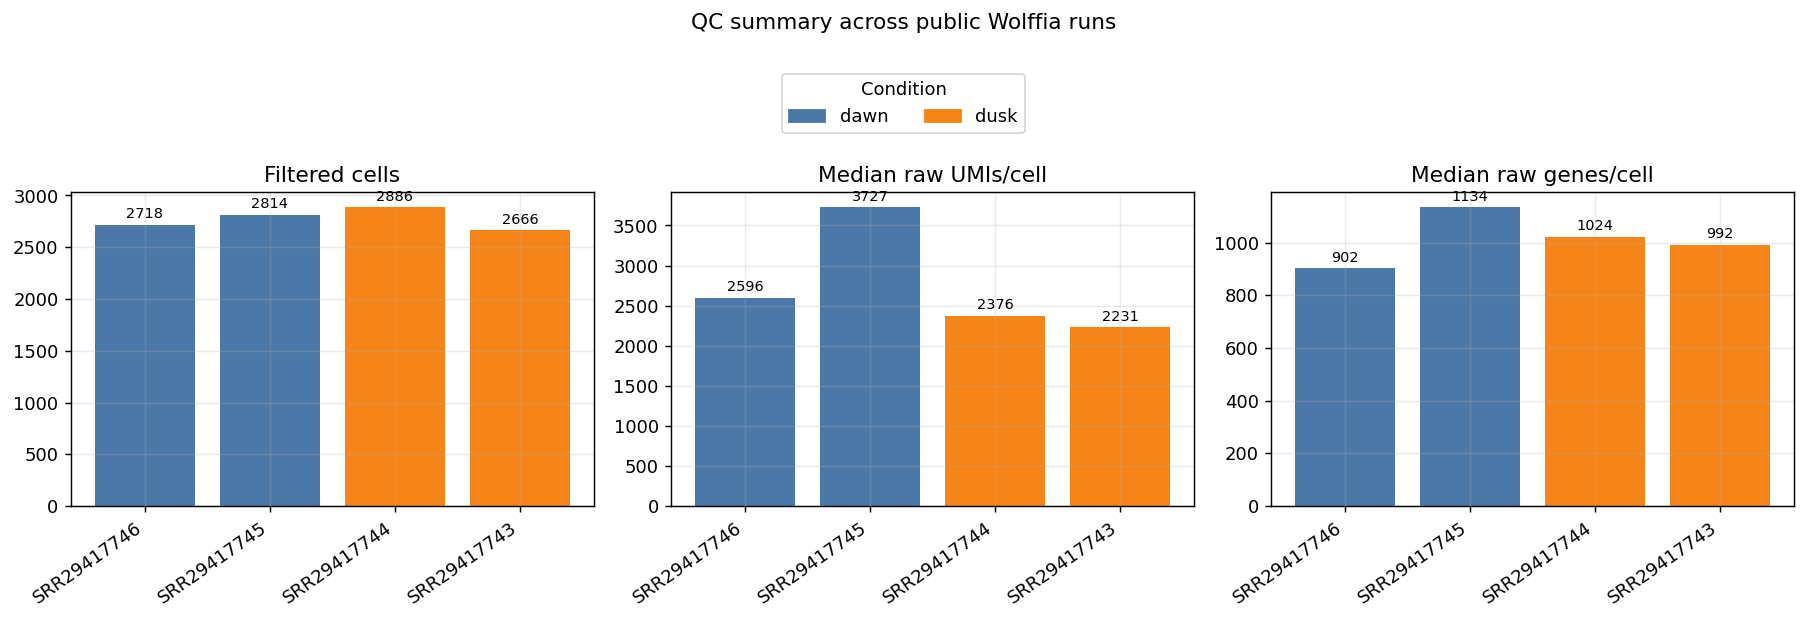

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
metrics = [
    ("cells", "Filtered cells"),
    ("median_raw_umis_per_cell", "Median raw UMIs/cell"),
    ("median_raw_genes_per_cell", "Median raw genes/cell"),
]

palette = {"dawn": "#4C78A8", "dusk": "#F58518"}
x = np.arange(len(comparison))
bar_colors = [palette.get(c, "#999999") for c in comparison["condition"]]

for ax, (metric, title) in zip(axes, metrics):
    bars = ax.bar(x, comparison[metric], color=bar_colors)
    ax.set_title(title)
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.set_xticks(x)
    ax.set_xticklabels(comparison["run"], rotation=35, ha="right")
    ax.bar_label(bars, fmt="%.0f", fontsize=8, padding=2)

handles = [plt.Rectangle((0, 0), 1, 1, color=palette[k]) for k in ["dawn", "dusk"]]
fig.legend(handles, ["dawn", "dusk"], title="Condition", loc="upper center", ncol=2, bbox_to_anchor=(0.5, 1.08))
fig.suptitle("QC summary across public Wolffia runs", y=1.18)
plt.tight_layout()
plt.show()


### 2. Feature coverage is stable across runs

Each run maps 309 of the 340 transfer-model features through the Waus8730 bridge. This means differences in accepted labels are not caused by a different model feature set across runs.


In [6]:
feature_view = comparison[[
    "run", "sample_alias", "condition", "mapped_model_features", "real_feature_coverage"
]].copy()
feature_view["real_feature_coverage_percent"] = 100 * feature_view["real_feature_coverage"]
feature_view


,run,sample_alias,condition,mapped_model_features,real_feature_coverage,real_feature_coverage_percent
0,SRR29417746,Dawn1,dawn,309,0.908824,90.882353
1,SRR29417745,Dawn2,dawn,309,0.908824,90.882353
2,SRR29417744,Dusk1,dusk,309,0.908824,90.882353
3,SRR29417743,Dusk2,dusk,309,0.908824,90.882353


### 3. The leaf-primary model accepts a small minority of cells; the root benchmark is nearly silent

This is expected for the current model hierarchy. The leaf-primary layer is the main Wolffia-facing interpretation layer, while the root benchmark is retained as a conservative secondary check.


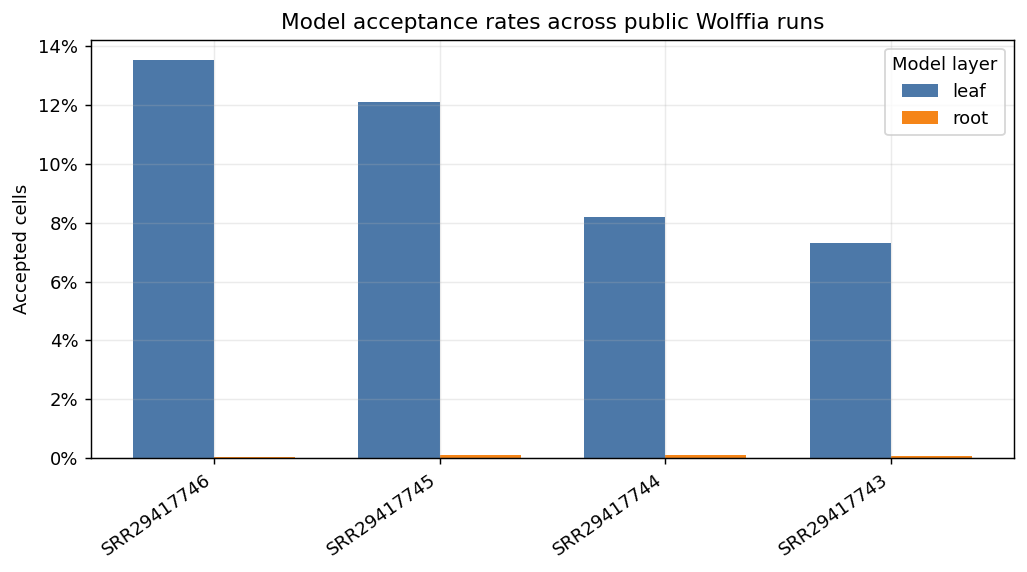

,run,condition,leaf_acceptance_rate,root_acceptance_rate
0,SRR29417746,dawn,0.135394,0.000368
1,SRR29417745,dawn,0.121180,0.001066
2,SRR29417744,dusk,0.081774,0.001040
3,SRR29417743,dusk,0.073143,0.000750


In [7]:
fig, ax = plt.subplots(figsize=(8, 4.5))
width = 0.36
x = np.arange(len(comparison))
leaf = comparison["leaf_acceptance_rate"].to_numpy()
root = comparison["root_acceptance_rate"].to_numpy()

ax.bar(x - width/2, leaf, width, label="leaf", color="#4C78A8")
ax.bar(x + width/2, root, width, label="root", color="#F58518")
ax.yaxis.set_major_formatter(lambda y, pos: f"{100*y:.0f}%")
ax.set_title("Model acceptance rates across public Wolffia runs")
ax.set_xlabel("")
ax.set_ylabel("Accepted cells")
ax.set_xticks(x)
ax.set_xticklabels(comparison["run"], rotation=35, ha="right")
ax.legend(title="Model layer")
plt.tight_layout()
plt.show()

comparison[["run", "condition", "leaf_acceptance_rate", "root_acceptance_rate"]]


### 4. The strongest recurring accepted label is photosynthetic/assimilation-like

Most cells remain ambiguous in every run, which is intentional: the model only accepts labels when both model families agree above the confidence threshold. Among accepted labels, `photosynthetic_or_assimilation` is the dominant reproducible signal.


/var/folders/w0/v9yy8dh97l5cbw6kwc8v949m0000gn/T/ipykernel_5515/1437575246.py:8: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  label_fraction = label_long.pivot_table(index="run", columns="label", values="fraction", fill_value=0)


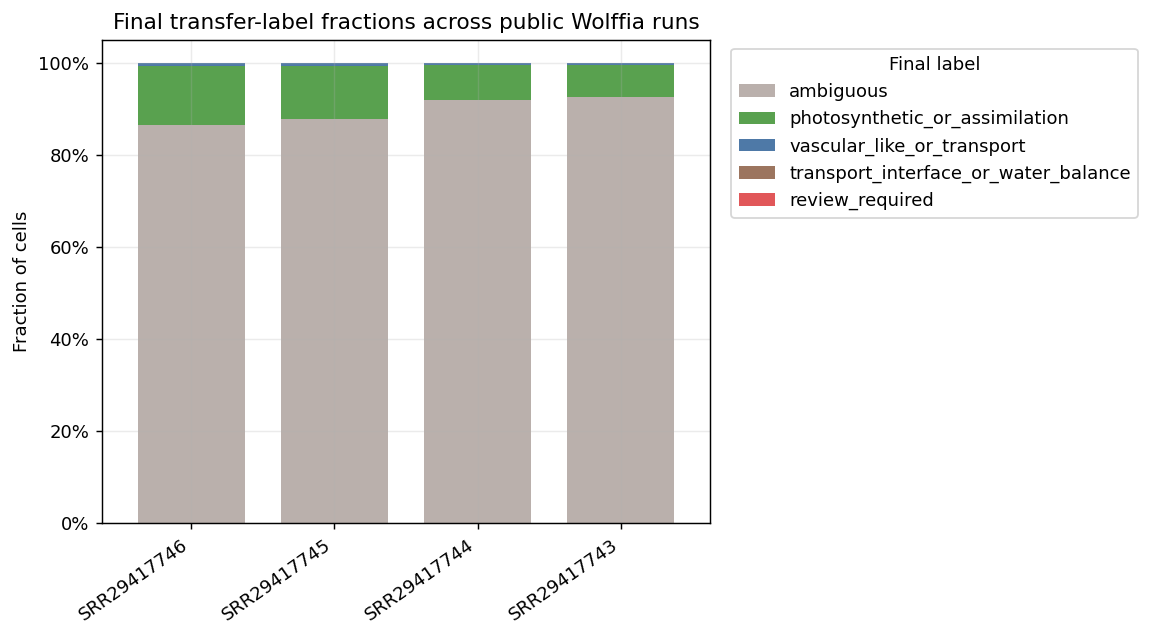

/var/folders/w0/v9yy8dh97l5cbw6kwc8v949m0000gn/T/ipykernel_5515/1437575246.py:35: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  label_counts_table = label_long.pivot_table(index=["run", "condition"], columns="label", values="n_cells", fill_value=0)


,label,ambiguous,photosynthetic_or_assimilation,vascular_like_or_transport,transport_interface_or_water_balance,review_required
run,condition,,,,,
SRR29417746,dawn,2350.0,347.0,21.0,0.0,0.0
SRR29417745,dawn,2473.0,322.0,16.0,2.0,1.0
SRR29417744,dusk,2650.0,224.0,11.0,0.0,1.0
SRR29417743,dusk,2471.0,183.0,10.0,2.0,0.0


In [8]:
plot_label_order = [
    "ambiguous",
    "photosynthetic_or_assimilation",
    "vascular_like_or_transport",
    "transport_interface_or_water_balance",
    "review_required",
]
label_fraction = label_long.pivot_table(index="run", columns="label", values="fraction", fill_value=0)
label_fraction = label_fraction.reindex(columns=plot_label_order, fill_value=0)

colors = {
    "ambiguous": "#BAB0AC",
    "photosynthetic_or_assimilation": "#59A14F",
    "vascular_like_or_transport": "#4E79A7",
    "transport_interface_or_water_balance": "#9C755F",
    "review_required": "#E15759",
}

ax = label_fraction.plot(
    kind="bar",
    stacked=True,
    figsize=(9, 5),
    color=[colors[c] for c in label_fraction.columns],
    width=0.75,
)
ax.yaxis.set_major_formatter(lambda x, pos: f"{100*x:.0f}%")
ax.set_title("Final transfer-label fractions across public Wolffia runs")
ax.set_xlabel("")
ax.set_ylabel("Fraction of cells")
ax.legend(title="Final label", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()

label_counts_table = label_long.pivot_table(index=["run", "condition"], columns="label", values="n_cells", fill_value=0)
label_counts_table = label_counts_table.reindex(columns=plot_label_order, fill_value=0)
label_counts_table


### 5. Dawn-labeled runs have higher leaf-primary acceptance than dusk-labeled runs in this processed set

This pattern is useful as a hypothesis, not yet a conclusion. It could reflect biology, sequencing depth, sample quality, or barcode/chemistry assumptions. A combined native UMAP and marker review is needed before interpreting this as a time-of-day effect.


In [9]:
condition_summary = (
    comparison
    .groupby("condition", dropna=False)
    .agg(
        runs=("run", "count"),
        mean_cells=("cells", "mean"),
        mean_median_umis=("median_raw_umis_per_cell", "mean"),
        mean_leaf_acceptance=("leaf_acceptance_rate", "mean"),
        mean_photosynthetic_fraction=("label_photosynthetic_or_assimilation", lambda s: s.sum() / comparison.loc[s.index, "cells"].sum()),
    )
    .reset_index()
)
condition_summary


,condition,runs,mean_cells,mean_median_umis,mean_leaf_acceptance,mean_photosynthetic_fraction
0,dawn,2,2766.0,3161.25,0.128287,0.120933
1,dusk,2,2776.0,2303.50,0.077459,0.073307


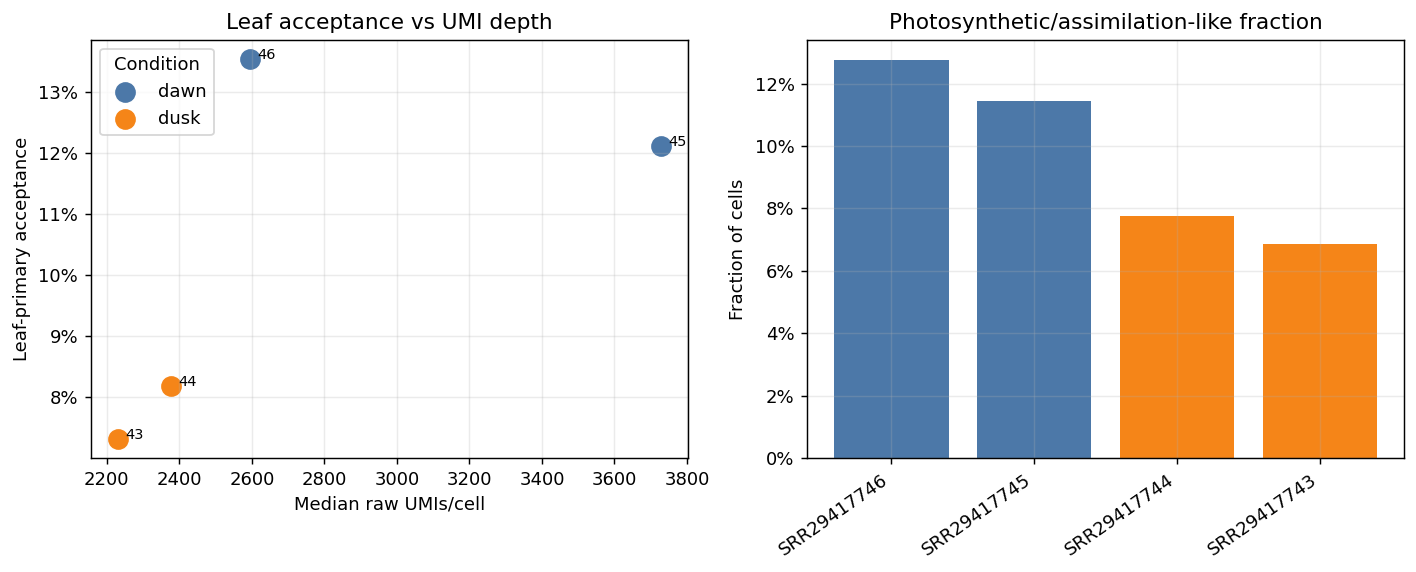

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

for condition, group in comparison.groupby("condition", dropna=False):
    axes[0].scatter(
        group["median_raw_umis_per_cell"],
        group["leaf_acceptance_rate"],
        label=condition,
        s=110,
        color=palette.get(condition, "#999999"),
    )
for _, row in comparison.iterrows():
    axes[0].text(row["median_raw_umis_per_cell"] + 20, row["leaf_acceptance_rate"], row["run"][-2:], fontsize=8)
axes[0].yaxis.set_major_formatter(lambda y, pos: f"{100*y:.0f}%")
axes[0].set_title("Leaf acceptance vs UMI depth")
axes[0].set_xlabel("Median raw UMIs/cell")
axes[0].set_ylabel("Leaf-primary acceptance")
axes[0].legend(title="Condition")

photo_fraction = comparison.copy()
photo_fraction["photosynthetic_fraction"] = photo_fraction["label_photosynthetic_or_assimilation"] / photo_fraction["cells"]
x = np.arange(len(photo_fraction))
bar_colors = [palette.get(c, "#999999") for c in photo_fraction["condition"]]
bars = axes[1].bar(x, photo_fraction["photosynthetic_fraction"], color=bar_colors)
axes[1].yaxis.set_major_formatter(lambda y, pos: f"{100*y:.0f}%")
axes[1].set_title("Photosynthetic/assimilation-like fraction")
axes[1].set_xlabel("")
axes[1].set_ylabel("Fraction of cells")
axes[1].set_xticks(x)
axes[1].set_xticklabels(photo_fraction["run"], rotation=35, ha="right")

plt.tight_layout()
plt.show()


## Takeaways

1. **The public Waus8730 workflow is now complete for the four available runs.** All four runs were processed through STARsolo, converted into AnnData, bridged into Arabidopsis model-feature space, and passed through the combined leaf-primary/root-benchmark model.
2. **The result is reproducible at the broad-program level.** All runs retain the same model feature coverage and produce a conservative label distribution dominated by ambiguous cells.
3. **The strongest current positive signal is photosynthetic/assimilation-like.** This label appears in every run and is much more common than vascular/transport-like or root-like signals.
4. **The root model behaves as expected.** It accepts almost no cells, which supports using it as a secondary benchmark rather than the main Wolffia interpretation layer.
5. **The next analysis should be native and cluster-aware.** A combined four-run UMAP and marker review should test whether the accepted labels occupy coherent Wolffia expression neighborhoods and whether the apparent dawn/dusk acceptance difference survives QC-aware review.
